## Simple Linear Regression

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Read the Dataset
df = pd.read_csv('height-weight.csv')

In [5]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Weight  23 non-null     int64
 1   Height  23 non-null     int64
dtypes: int64(2)
memory usage: 500.0 bytes


Text(0, 0.5, 'Height')

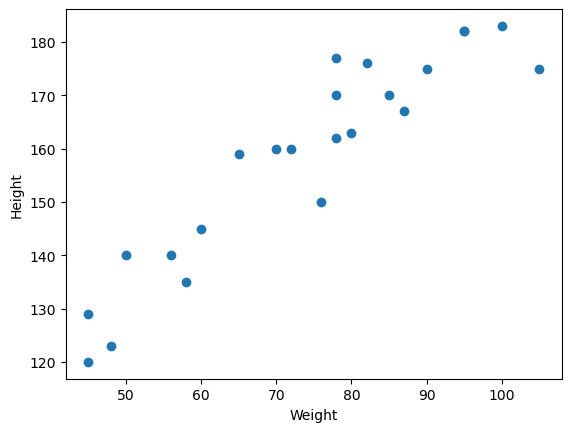

In [7]:
plt.scatter(df['Weight'], df['Height'])
plt.xlabel("Weight")
plt.ylabel("Height")

In [15]:
# Divide Dataset into independent and dependent features
X = df[['Weight']] # independent feature
y = df['Height'] # dependent deature

In [16]:
# Train Test Split

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20,random_state=42)

In [17]:
X.shape, X_train.shape, X_test.shape

((23, 1), (18, 1), (5, 1))

In [18]:
y.shape, y_train.shape, y_test.shape

((23,), (18,), (5,))

In [19]:
## Standardize the Train independent data

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [21]:
X_train = scaler.fit_transform(X_train)

In [27]:
X_test = scaler.transform(X_test)

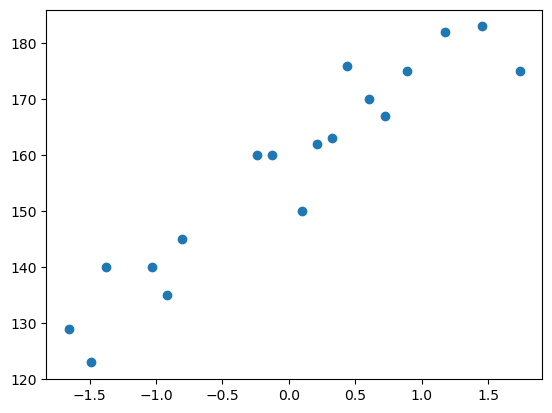

In [29]:
plt.scatter(X_train, y_train)

In [30]:
## Train the Simple Linear Regression

from sklearn.linear_model import LinearRegression
regressor = LinearRegression()

In [31]:
regressor.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [35]:
print("The Slope or Coefficient of weight is :",regressor.coef_)
print("The Intercept is :", regressor.intercept_)

The Slope or Coefficient of weight is : [17.03440872]
The Intercept is : 157.5


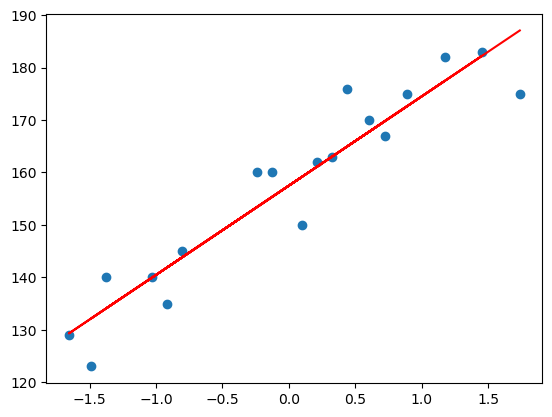

In [38]:
# Create the Best Fit Line
plt.scatter(X_train, y_train)
plt.plot(X_train, regressor.predict(X_train), color='r')

### Prediction of Trained data
1. predcited height output = intercept + coef_(Weight)
2. y_pred_train = 157.5 + 17.03(X_train)

### Prediction of Test data
1. predcited height output = intercept + coef_(Weight)
2. y_pred_test = 157.5 + 17.03(X_test)

In [39]:
y_pred_test = regressor.predict(X_test)

In [40]:
y_pred_test, y_test

(array([161.08467086, 161.08467086, 129.3041561 , 177.45645118,
        148.56507414]),
 15    177
 9     170
 0     120
 8     182
 17    159
 Name: Height, dtype: int64)

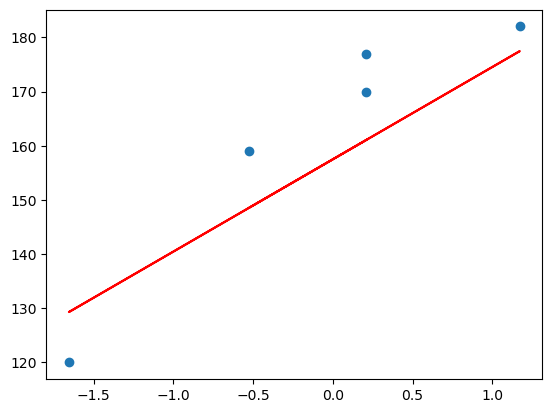

In [42]:
plt.scatter(X_test, y_test)
plt.plot(X_test, regressor.predict(X_test), color='r')

In [44]:
# Compute R2 and Adjusted R2

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [45]:
mse = mean_squared_error(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
print("MSE :", mse)
print("MAE :", mae)
print("RMSE :", rmse)

MSE : 109.77592599051664
MAE : 9.822657814519232
RMSE : 10.477400726827081


In [46]:
score = r2_score(y_test, y_pred_test)
print("R2 Score :", score)

R2 Score : 0.776986986042344


In [49]:
# Adjusted R2

Adjusted = 1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)
print("Adjusted R2 :", Adjusted)

Adjusted R2 : 0.7026493147231252
